# VGG11 on CIFAR-10 (PyTorch)

Experimenting with the VGG11 architecture on the CIFAR-10 dataset as part of a comparative study of CNN architectures.

- **Framework:** PyTorch
- **Dataset:** CIFAR-10 (60,000 images, 10 classes)
- **Optimizer:** Adam | **Loss:** CrossEntropyLoss | **Epochs:** 10
- **Hardware:** GPU (Google Colab T4)

## 1. Importing Libraries

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision.utils import make_grid
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Data Preprocessing
Applying data augmentation on training set (RandomCrop, RandomHorizontalFlip) to improve generalization.
Test set uses only normalization — no augmentation.
Pixel values normalized to [-1, 1] range using mean and std of 0.5 per channel.

In [2]:
data_statistics = ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

## 3. Loading CIFAR-10 and Creating DataLoaders
Splitting training data into 80% train and 20% validation sets.
Batch size: 64, num_workers: 2 (optimized for GPU throughput).

In [3]:
dataset = torchvision.datasets.CIFAR10(root='data/', download=True, transform=train_transforms)
test_dataset = torchvision.datasets.CIFAR10(root='data/', download=True, train=False, transform=test_transforms)

val_ratio = 0.2
train_len = int((1 - val_ratio) * len(dataset))
val_len = len(dataset) - train_len
train_dataset, val_dataset = random_split(dataset, [train_len, val_len])

batch_size = 64

train_dl = DataLoader(train_dataset, batch_size, shuffle=True, pin_memory=True, num_workers=2, persistent_workers=True)
val_dl = DataLoader(val_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)
test_dl = DataLoader(test_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)

print(f"Train size: {train_len} | Val size: {val_len} | Test size: {len(test_dataset)}")
print(f"Dataloaders initialized with batch size: {batch_size}")

100%|██████████| 170M/170M [00:14<00:00, 11.9MB/s]


Train size: 40000 | Val size: 10000 | Test size: 10000
Dataloaders initialized with batch size: 64


## 4. Data Exploration
Visualizing a batch of training images to verify data loading and augmentation pipeline.

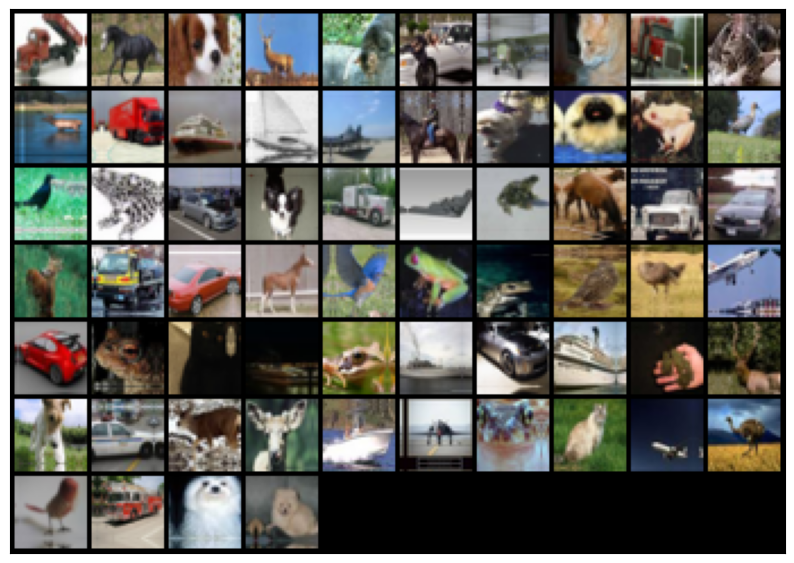

In [4]:
def denormalize(images, means, std_devs):
    dev = images.device
    means = torch.tensor(means).reshape(1, 3, 1, 1).to(dev)
    std_devs = torch.tensor(std_devs).reshape(1, 3, 1, 1).to(dev)
    return images * std_devs + means

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(10, 10))
        images = denormalize(images, *data_statistics)
        grid = make_grid(images, nrow=10).cpu().permute(1, 2, 0)
        ax.imshow(grid)
        ax.set_xticks([])
        ax.set_yticks([])
        break

show_batch(train_dl)

## 5. Device Utilities
Helper functions and wrapper class to move data and models to GPU automatically.

In [5]:
def to_device(entity, device):
    if isinstance(entity, (list, tuple)):
        return [to_device(elem, device) for elem in entity]
    if hasattr(entity, 'to'):
        return entity.to(device, non_blocking=True)
    return entity

class DeviceDataLoader():
    """Wrapper around DataLoader to transfer batches to specified device."""
    def __init__(self, dataloader, device):
        self.dl = dataloader
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)
print(f"Data wrappers initialized on: {device}")

Data wrappers initialized on: cuda


## 6. Model Architecture — VGG11
Standard VGG11 with BatchNorm from torchvision.models, modified for CIFAR-10.
The classifier head is replaced to reduce parameters and suit 32x32 input images.

| Component | Details |
|-----------|---------|
| Base Model | VGG11_BN (torchvision.models) |
| Pretrained | False — trained from scratch |
| Conv Layers | 8 conv layers with BatchNorm |
| Pooling | AdaptiveAvgPool2d(1,1) — modified for small images |
| Classifier | Linear(512, 256) → ReLU → Dropout → Linear(256, 10) |

- **Activation:** ReLU
- **Regularization:** BatchNorm2d + Dropout(0.5)
- **Activation:** ReLU
- **Regularization:** BatchNorm2d + Dropout

In [6]:
def build_model():
    m = models.vgg11_bn(weights=None)
    m.classifier[6] = nn.Linear(4096, 10)
    m.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    m.classifier = nn.Sequential(
        nn.Linear(512, 256),
        nn.ReLU(True),
        nn.Dropout(0.5),
        nn.Linear(256, 10)
    )
    return m

model = to_device(build_model(), device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 9,359,882


## 7. Training Utilities
- `accuracy()` computes batch-level classification accuracy
- `evaluate()` runs the model in eval mode over a dataloader
- `train()` runs the full training loop with OneCycleLR scheduler and gradient clipping

In [7]:
def accuracy(logits, labels):
    _, predClassId = torch.max(logits, dim=1)
    return torch.tensor(torch.sum(predClassId == labels).item() / len(logits))

def evaluate(model, dl, loss_func):
    batch_losses, batch_accs = [], []
    model.eval()
    for images, labels in dl:
        with torch.no_grad():
            logits = model(images)
        batch_losses.append(loss_func(logits, labels))
        batch_accs.append(accuracy(logits, labels))
    epoch_avg_loss = torch.stack(batch_losses).mean().item()
    epoch_avg_acc = torch.stack(batch_accs).mean().item()
    return epoch_avg_loss, epoch_avg_acc

def train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim):
    optimizer = optim(model.parameters(), max_lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_dl))

    results = []
    lrs = []
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for images, labels in train_dl:
            logits = model(images)
            loss = loss_func(logits, labels)
            train_losses.append(loss.detach())

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.1)
            optimizer.step()
            optimizer.zero_grad()

            lrs.append(optimizer.param_groups[0]["lr"])
            scheduler.step()

        epoch_train_loss = torch.stack(train_losses).mean().item()

        model.eval()
        batch_losses, batch_accs = [], []
        for images, labels in val_dl:
            with torch.no_grad():
                logits = model(images)
            batch_losses.append(loss_func(logits, labels))
            batch_accs.append(accuracy(logits, labels))

        epoch_avg_loss = torch.stack(batch_losses).mean().item()
        epoch_avg_acc = torch.stack(batch_accs).mean().item()

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_avg_loss:.4f} | Val Acc: {epoch_avg_acc:.4f}")

        results.append({
            'avg_valid_loss': epoch_avg_loss,
            'avg_valid_acc': epoch_avg_acc,
            'avg_train_loss': epoch_train_loss
        })

    return results, lrs

## 8. Training
Training VGG11 for 10 epochs using Adam optimizer with OneCycleLR scheduler and gradient clipping (max_norm=0.1).
Weight decay of 1e-4 applied for regularization.

In [8]:
epochs = 10
max_lr = 1e-2
loss_func = nn.functional.cross_entropy
optim = torch.optim.Adam

start_time = time.time()
results, lrs = train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim)
end_time = time.time()

training_time = end_time - start_time
print(f"\nTraining complete. Training Time: {training_time:.2f} seconds")

Epoch [1/10] | Train Loss: 1.6848 | Val Loss: 1.9020 | Val Acc: 0.2373
Epoch [2/10] | Train Loss: 1.8130 | Val Loss: 2.0246 | Val Acc: 0.2442
Epoch [3/10] | Train Loss: 1.7101 | Val Loss: 1.7446 | Val Acc: 0.3370
Epoch [4/10] | Train Loss: 1.6314 | Val Loss: 2.0267 | Val Acc: 0.3013
Epoch [5/10] | Train Loss: 1.5718 | Val Loss: 1.6332 | Val Acc: 0.3861
Epoch [6/10] | Train Loss: 1.4827 | Val Loss: 1.3890 | Val Acc: 0.4660
Epoch [7/10] | Train Loss: 1.4035 | Val Loss: 1.3374 | Val Acc: 0.4804
Epoch [8/10] | Train Loss: 1.3207 | Val Loss: 1.2729 | Val Acc: 0.5312
Epoch [9/10] | Train Loss: 1.2468 | Val Loss: 1.1453 | Val Acc: 0.5703
Epoch [10/10] | Train Loss: 1.2073 | Val Loss: 1.1258 | Val Acc: 0.5786

Training complete. Training Time: 290.77 seconds


## 9. Training Curves
Plotting validation accuracy, train/val loss, and learning rate schedule across epochs.

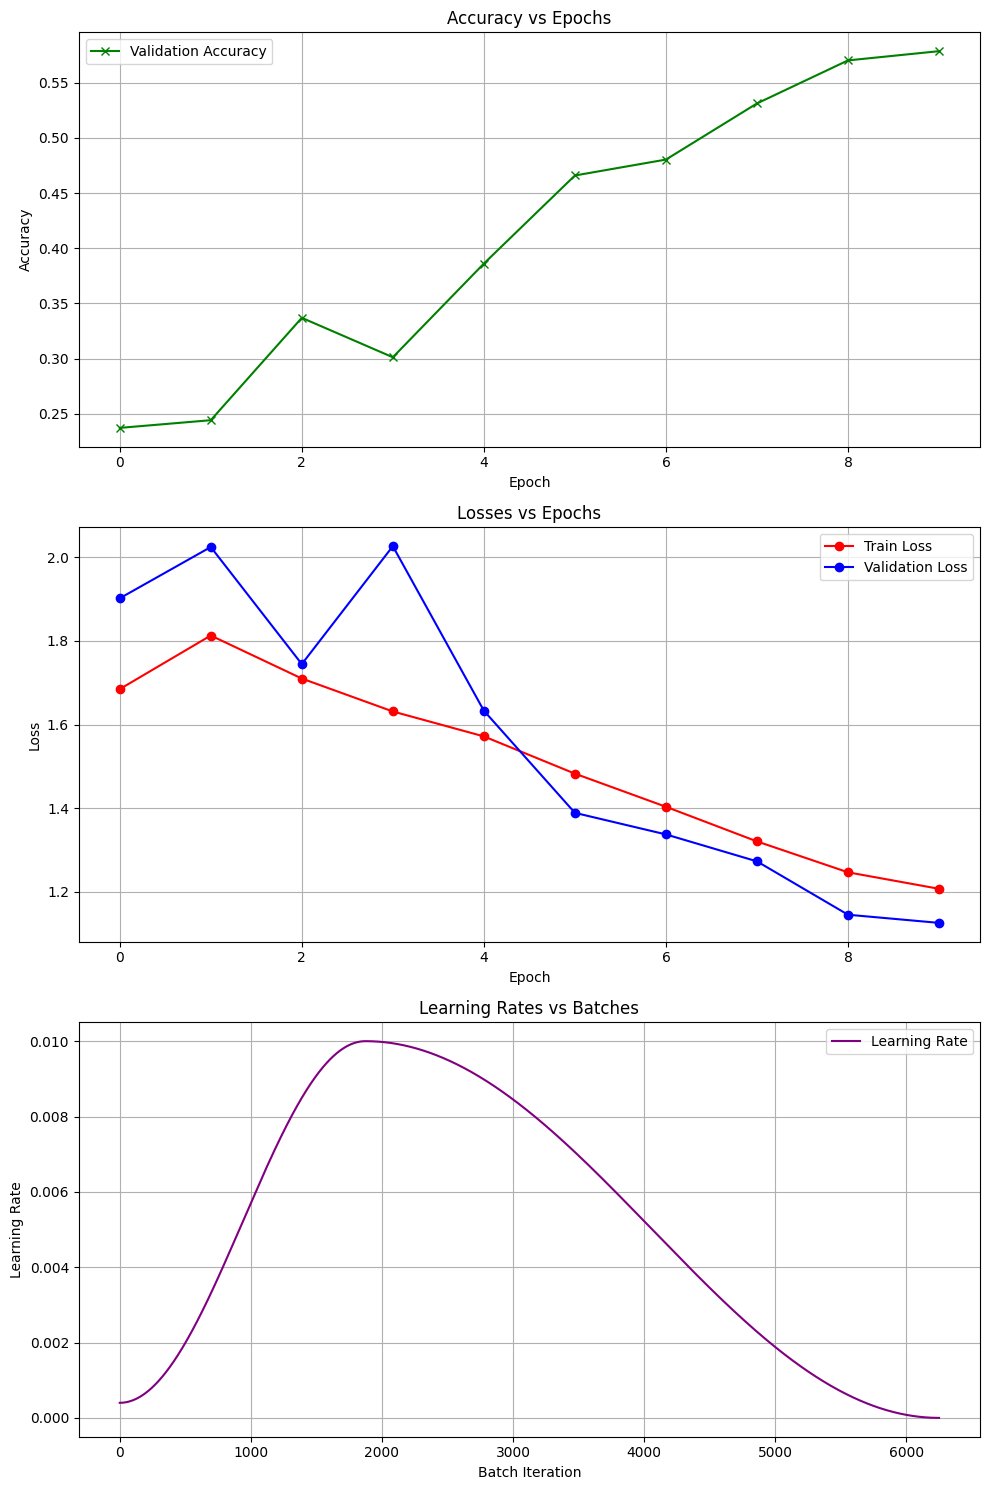

In [9]:
def plot_metrics(results, lrs):
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))

    val_accs = [r['avg_valid_acc'] for r in results]
    axes[0].plot(val_accs, '-x', color='green', label='Validation Accuracy')
    axes[0].set_title('Accuracy vs Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    train_losses = [r['avg_train_loss'] for r in results]
    val_losses = [r['avg_valid_loss'] for r in results]
    axes[1].plot(train_losses, '-o', color='red', label='Train Loss')
    axes[1].plot(val_losses, '-o', color='blue', label='Validation Loss')
    axes[1].set_title('Losses vs Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(lrs, color='purple', label='Learning Rate')
    axes[2].set_title('Learning Rates vs Batches')
    axes[2].set_xlabel('Batch Iteration')
    axes[2].set_ylabel('Learning Rate')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_metrics(results, lrs)

## 10. Saving and Evaluating the Model
Saving trained weights, then verifying the save/load pipeline by evaluating both the original and reloaded model.
Both should produce identical test accuracy.

In [10]:
_, test_acc = evaluate(model, test_dl, loss_func)
print(f"Original model test accuracy: {test_acc:.4f}")

torch.save(model.state_dict(), 'cifar10_vgg11.pth')

# Reload and verify
model_reload = build_model()
model_reload = to_device(model_reload, device)
model_reload.load_state_dict(torch.load('cifar10_vgg11.pth', weights_only=True))
_, test_acc2 = evaluate(model_reload, test_dl, loss_func)
print(f"Reloaded model test accuracy: {test_acc2:.4f}")

Original model test accuracy: 0.6009
Reloaded model test accuracy: 0.6009


## 11. Results Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | *60.09%* |
| Trainable Parameters | *9,359,882* |
| Training Time | *290.77 seconds(4.84616667 minutes)* |
| Hardware | GPU (Google Colab T4) |
| Epochs | 10 |
| Optimizer | Adam + OneCycleLR |

**Observation:** VGG11 achieves 60.09% test accuracy on CIFAR-10, the lowest among all three
architectures tested despite having 9,359,882 trainable parameters.

The accuracy curve shows significant instability in the first 4 epochs, dropping
at epochs 1 and 3 before recovering. This is caused by the aggressive learning
rate warmup phase of OneCycleLR interacting poorly with VGG11's large fully
connected layers.

The loss curves confirm the instability — validation loss spikes at epochs 1 and 3
while train loss increases slightly at epoch 1, indicating the model struggles to
adapt during the warmup phase. From epoch 4 onward both losses decrease steadily
and converge closely, showing no overfitting.

VGG11's poor performance relative to the baseline CNN is primarily due to its
architecture being designed for large input images (224x224). On 32x32 CIFAR-10
images, the five MaxPool layers aggressively reduce spatial dimensions, leaving
very little spatial information for the classifier. The model was still improving
at epoch 9, suggesting significantly more epochs would be needed to reach
competitive accuracy.